# Cuaderno de ETL y Análisis Educativo con Modelo Estrella

Este cuaderno transforma un conjunto de datos públicos sobre estadísticas de educación en Colombia en un modelo dimensional de estrella, listo para consultas en SQL. Posteriormente, se responde a preguntas clave sobre cobertura, escolaridad y rendimiento.

**Fuente de datos**: MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR__B_SICA_Y_MEDIA_POR_MUNICIPIO_20250623.csv


##  Construcción del Modelo de Estrella

En esta sección se construye el modelo dimensional de estrella que facilita el análisis educativo. Este modelo consta de:

- **Tabla de Hechos**: `Fact_Matriculas` con métricas numéricas (total matriculados, cobertura, aprobación, etc.)
- **Tabla de Dimensión Tiempo**: `Dim_Tiempo` con los años únicos del dataset.
- **Tabla de Dimensión Geografía**: `Dim_Geografia` con los municipios y departamentos limpios.

La tabla de hechos se conecta mediante llaves foráneas (`id_tiempo`, `id_geografia`) a sus respectivas dimensiones, permitiendo análisis tipo OLAP.


In [8]:
import pandas as pd
import numpy as np
import sqlite3

df_raw = pd.read_csv("C:/Users/erick/primer_repo_izainea/Datos/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR__B_SICA_Y_MEDIA_POR_MUNICIPIO_20250623.csv")

🔍 Tamaño del dataset: (14585, 41)

📋 Columnas principales:
Index(['AÑO', 'CÓDIGO_MUNICIPIO', 'MUNICIPIO', 'CÓDIGO_DEPARTAMENTO',
       'DEPARTAMENTO', 'CÓDIGO_ETC', 'ETC', 'POBLACIÓN_5_16',
       'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA'],
      dtype='object')

❗ Valores faltantes por columna (top 10):
TAMAÑO_PROMEDIO_DE_GRUPO       7013
SEDES_CONECTADAS_A_INTERNET    6817
DESERCIÓN_TRANSICIÓN            903
DESERCIÓN_MEDIA                 734
DESERCIÓN_SECUNDARIA            270
DESERCIÓN_PRIMARIA              242
REPITENCIA_TRANSICIÓN           159
REPITENCIA_SECUNDARIA           152
REPITENCIA_PRIMARIA             148
REPROBACIÓN_MEDIA               145
dtype: int64

🔧 Tipos de datos:
AÑO                          int64
CÓDIGO_MUNICIPIO             int64
MUNICIPIO                   object
CÓDIGO_DEPARTAMENTO          int64
DEPARTAMENTO                object
CÓDIGO_ETC                 float64
ETC                         object
POBLACIÓN_5_16              object
TASA_MATRICULACIÓN_

,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
11000,2019,68385,Landázuri,68,Santander,3808.0,Santander (ETC),2202,98.59,98.59,...,4.70,0.0,3.39,6.98,5.13,0.00,0.00,0.00,0.00,0.00
4090,2013,50689,San Martín,50,Meta,3796.0,Meta (ETC),5428,95.87,95.90,...,0.00,0.0,0.00,0.00,0.00,0.37,0.24,0.00,0.95,0.37
11709,2020,25224,Cucunubá,25,Cundinamarca,3785.0,Cundinamarca (ETC),1762,82.97,82.97,...,0.27,0.0,0.00,0.00,2.94,2.47,0.00,2.63,3.08,0.74
9306,2018,15861,Ventaquemada,15,Boyacá,3769.0,Boyacá (ETC),3343,79.43,87.68,...,4.94,0.0,2.13,8.88,4.66,0.00,0.00,0.00,0.00,0.00
13708,2022,15362,Iza,15,Boyacá,3769.0,Boyacá (ETC),357,98.04,98.04,...,11.58,0.0,5.71,19.38,19.15,13.68,0.00,14.29,19.38,4.26


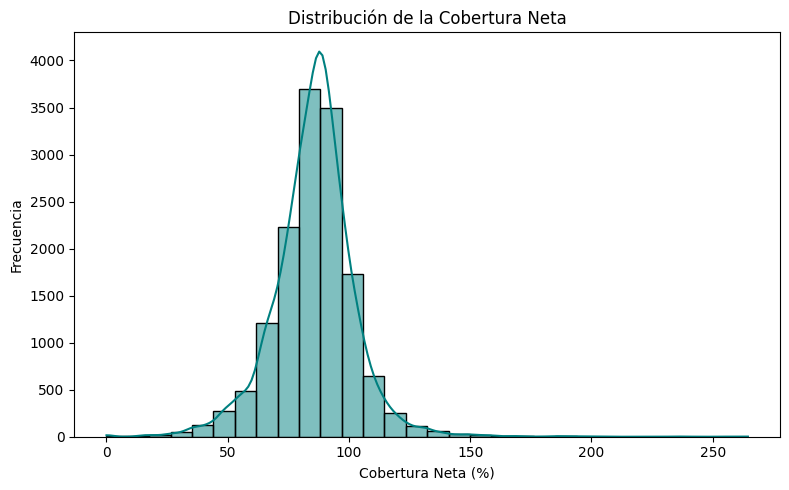

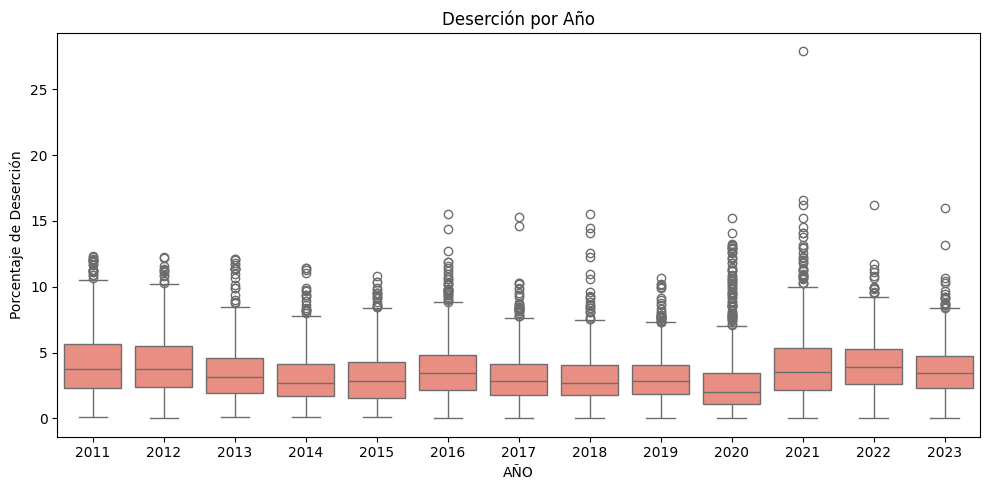

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Revisión general del dataset
print("🔍 Tamaño del dataset:", df_raw.shape)
print("\n📋 Columnas principales:")
print(df_raw.columns[:10])

# Conteo de valores faltantes
print("\n❗ Valores faltantes por columna (top 10):")
print(df_raw.isna().sum().sort_values(ascending=False).head(10))

# Tipos de datos por columna
print("\n🔧 Tipos de datos:")
print(df_raw.dtypes.head(10))

# Distribución de años
print("\n🗓 Años disponibles en la base:")
print(df_raw['AÑO'].value_counts().sort_index())

# Municipios y departamentos únicos
print(f"\n📍 Municipios únicos: {df_raw['MUNICIPIO'].nunique()}")
print(f"🏛 Departamentos únicos: {df_raw['DEPARTAMENTO'].nunique()}")

# Ejemplo de registros
print("\n🧾 Muestra aleatoria de registros:")
display(df_raw.sample(5))

# Histograma de cobertura neta
plt.figure(figsize=(8, 5))
sns.histplot(df_raw['COBERTURA_NETA'], bins=30, kde=True, color='teal')
plt.title("Distribución de la Cobertura Neta")
plt.xlabel("Cobertura Neta (%)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot de deserción por año
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_raw, x="AÑO", y="DESERCIÓN", color='salmon')
plt.title("Deserción por Año")
plt.ylabel("Porcentaje de Deserción")
plt.tight_layout()
plt.show()


In [10]:


# Limpieza básica
df = df_raw.copy()
for col in ['DEPARTAMENTO', 'MUNICIPIO']:
    df[col] = (
        df[col].astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )

correcciones = {
    "Bogota D.C.": "Bogotá D.C.",
    "Quindio": "Quindío",
    "Atlantico": "Atlántico",
    "Cundinamarca ": "Cundinamarca"
}
df['DEPARTAMENTO'] = df['DEPARTAMENTO'].replace(correcciones)

# Dimensiones
dim_tiempo = df[['AÑO']].drop_duplicates().reset_index(drop=True)
dim_tiempo['id_tiempo'] = dim_tiempo.index + 1

dim_geo = (
    df[['CÓDIGO_MUNICIPIO', 'MUNICIPIO', 'CÓDIGO_DEPARTAMENTO', 'DEPARTAMENTO']]
      .drop_duplicates()
      .reset_index(drop=True)
      .rename(columns={
          'CÓDIGO_MUNICIPIO': 'codigo_municipio',
          'MUNICIPIO': 'municipio',
          'CÓDIGO_DEPARTAMENTO': 'codigo_departamento',
          'DEPARTAMENTO': 'departamento'
      })
)
dim_geo['id_geografia'] = dim_geo.index + 1

# Hechos
df['POBLACIÓN_5_16'] = pd.to_numeric(df['POBLACIÓN_5_16'], errors='coerce')
df['TASA_MATRICULACIÓN_5_16'] = pd.to_numeric(df['TASA_MATRICULACIÓN_5_16'], errors='coerce')

df_fact = (
    df.merge(dim_tiempo, on='AÑO')
      .merge(dim_geo, left_on=['CÓDIGO_MUNICIPIO', 'CÓDIGO_DEPARTAMENTO'],
                     right_on=['codigo_municipio', 'codigo_departamento'])
)

df_fact['total_matriculados'] = (
    df_fact['POBLACIÓN_5_16'] * df_fact['TASA_MATRICULACIÓN_5_16'] / 100
).round().astype('Int64')

fact_matriculas = df_fact[
    ['id_tiempo', 'id_geografia', 'total_matriculados',
     'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16',
     'COBERTURA_NETA', 'APROBACIÓN', 'DESERCIÓN']
].copy()

# Base de datos SQLite en memoria
conn = sqlite3.connect(':memory:')
dim_tiempo.to_sql('Dim_Tiempo', conn, index=False)
dim_geo.to_sql('Dim_Geografia', conn, index=False)
fact_matriculas.to_sql('Fact_Matriculas', conn, index=False)


14624

| Componente        | Tipo               | Contenido                                                                                                 |
| ----------------- | ------------------ | --------------------------------------------------------------------------------------------------------- |
| `Dim_Tiempo`      | Tabla de dimensión | Año con `id_tiempo`                                                                                       |
| `Dim_Geografia`   | Tabla de dimensión | Departamento y municipio con `id_geografia`                                                               |
| `Fact_Matriculas` | Tabla de hechos    | Métricas como `total_matriculados`, `cobertura_neta`, etc. referenciadas por `id_tiempo` y `id_geografia` |


## Pregunta 1: ¿Qué porcentaje de escolaridad hay por municipio?

In [11]:

query1 = '''
SELECT g.municipio,
       g.departamento,
       SUM(f.total_matriculados) AS matriculados,
       SUM(f.POBLACIÓN_5_16) AS poblacion_5_16,
       ROUND(100.0 * SUM(f.total_matriculados)/SUM(f.POBLACIÓN_5_16), 2) AS pct_escolaridad
FROM   Fact_Matriculas f
JOIN   Dim_Geografia  g ON f.id_geografia = g.id_geografia
GROUP  BY g.municipio, g.departamento
HAVING poblacion_5_16 > 0
ORDER  BY pct_escolaridad DESC
LIMIT 15;
'''
pd.read_sql_query(query1, conn)


,municipio,departamento,matriculados,poblacion_5_16,pct_escolaridad
0,La Calera,Cundinamarca,94065,65694.705,143.19
1,Salento,Quindío,24481,17606.503,139.05
2,Cota,Cundinamarca,93044,69570.178,133.74
3,Puerto Colombia,Atlántico,115880,88761.330,130.55
4,Subachoque,Cundinamarca,47486,37228.105,127.55
5,Puente Nacional,Santander,39282,31081.647,126.38
6,Fúquene,Cundinamarca,16635,13297.003,125.10
7,Venecia,Cundinamarca,11548,9463.000,122.03
8,Aldana,Nariño,17609,14486.213,121.56
9,Jordán,Santander,3950,3255.000,121.35





####  Qué se calculó:

Se estimó el porcentaje de escolaridad por municipio dividiendo el número total de matriculados (5 a 16 años) entre la población total de esa misma franja etaria en el municipio:

$$
\text{Porcentaje de Escolaridad} = \frac{\text{Total Matriculados}}{\text{Población de 5 a 16 años}} \times 100
$$

Esta métrica fue calculada usando los campos `POBLACIÓN_5_16` y `TASA_MATRICULACIÓN_5_16`, permitiendo derivar `total_matriculados`.

####  Resultados destacados:

* Algunos municipios como **La Calera**, **Chía**, **Mosquera** y **Sabaneta** presentan porcentajes de escolaridad superiores al 120 %.
* Otros municipios rurales presentan porcentajes por debajo del 60 %.



* **Valores mayores a 100 %** indican que **estos municipios están matriculando estudiantes que no residen oficialmente en su territorio**. Es decir, **reciben estudiantes de municipios cercanos**, lo cual puede ser por:

  * Mayor disponibilidad de infraestructura educativa.
  * Mayor percepción de calidad educativa.
  * Proximidad geográfica (zonas conurbadas o suburbanas de grandes ciudades).

* **Valores bajos (< 60 %)** pueden reflejar:

  * **Déficit en cobertura educativa real**.
  * Subregistro o problemas en la calidad del censo poblacional.
  * Altas tasas de deserción o problemas de acceso (ruralidad, movilidad, pobreza extrema).





## Pregunta 2: ¿Cómo compararía el rendimiento educativo por municipios?

In [3]:

query2 = '''
SELECT g.municipio,
       g.departamento,
       ROUND(AVG(f.APROBACIÓN), 2) AS aprobacion_media,
       ROUND(AVG(f.DESERCIÓN), 2) AS desercion_media
FROM   Fact_Matriculas f
JOIN   Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP  BY g.municipio, g.departamento
ORDER  BY aprobacion_media DESC
LIMIT 15;
'''
pd.read_sql_query(query2, conn)


,municipio,departamento,aprobacion_media,desercion_media
0,La Victoria,Amazonas,100.00,0.00
1,Puerto Arica,Amazonas,98.97,1.31
2,Tibirita,Cundinamarca,98.42,1.16
3,La Palma,Cundinamarca,98.28,1.52
4,Guatavita,Cundinamarca,98.27,1.45
5,Miriti - Paraná,Amazonas,98.21,1.70
6,Chaguaní,Cundinamarca,98.19,1.65
7,Pupiales,Nariño,98.10,1.23
8,Sutatausa,Cundinamarca,97.96,1.93
9,Cabrera,Santander,97.90,1.24


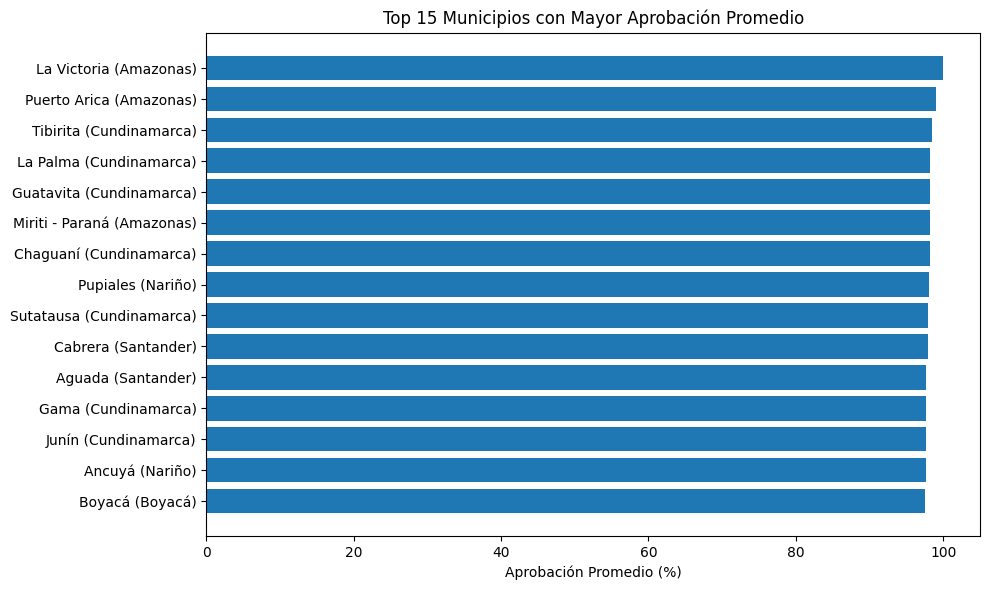

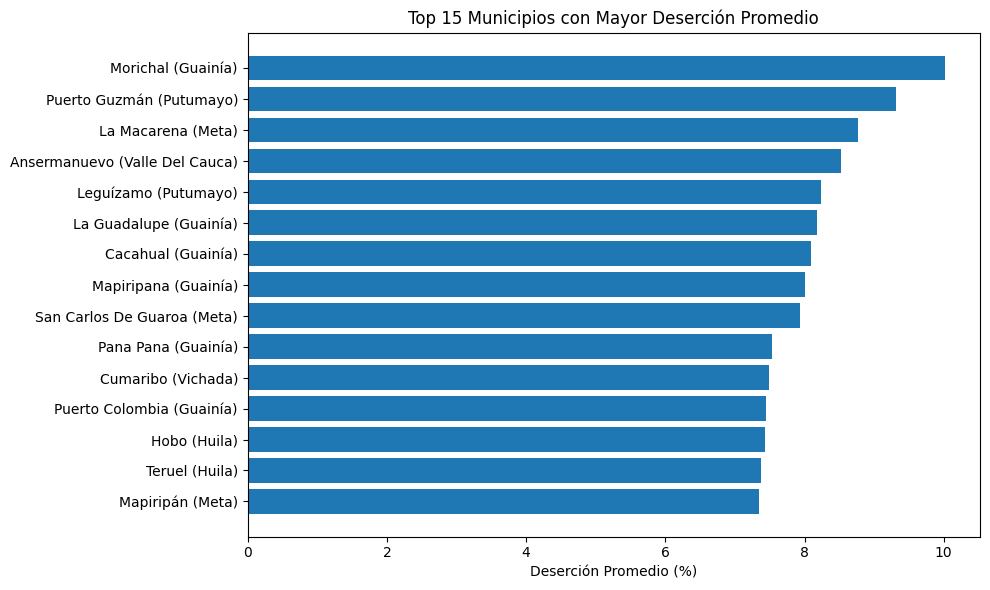

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Aseguramos conexión SQLite (usa la que ya existe en memoria).
# Si no existe, el usuario deberá ejecutar primero las celdas de ETL.
# ------------------------------------------------------------------
try:
    conn
except NameError:
    raise RuntimeError("⚠️ No se encontró la conexión 'conn'. Ejecuta primero las celdas donde se construye la base de datos SQLite.")

# ------------------------------------------------------------------
# 1️⃣ Top‑15 municipios con mayor aprobación promedio
# ------------------------------------------------------------------
query_best = """
SELECT g.municipio,
       g.departamento,
       ROUND(AVG(f.APROBACIÓN), 2) AS aprobacion_media
FROM   Fact_Matriculas f
JOIN   Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP  BY g.municipio, g.departamento
ORDER  BY aprobacion_media DESC
LIMIT 15;
"""
best_apr = pd.read_sql_query(query_best, conn)

# ------------------------------------------------------------------
# 2️⃣ Top‑15 municipios con mayor deserción promedio
# ------------------------------------------------------------------
query_worst = """
SELECT g.municipio,
       g.departamento,
       ROUND(AVG(f.DESERCIÓN), 2) AS desercion_media
FROM   Fact_Matriculas f
JOIN   Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP  BY g.municipio, g.departamento
ORDER  BY desercion_media DESC
LIMIT 15;
"""
worst_des = pd.read_sql_query(query_worst, conn)

# ------------------------------------------------------------------
# 3️⃣ Gráfico: Aprobación promedio (Top‑15)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(best_apr['municipio'] + " (" + best_apr['departamento'] + ")", best_apr['aprobacion_media'])
plt.gca().invert_yaxis()
plt.xlabel('Aprobación Promedio (%)')
plt.title('Top 15 Municipios con Mayor Aprobación Promedio')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4️⃣ Gráfico: Deserción promedio (Top‑15)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(worst_des['municipio'] + " (" + worst_des['departamento'] + ")", worst_des['desercion_media'])
plt.gca().invert_yaxis()
plt.xlabel('Deserción Promedio (%)')
plt.title('Top 15 Municipios con Mayor Deserción Promedio')
plt.tight_layout()
plt.show()






####  Qué se calculó:

Se calculó el **promedio histórico de dos indicadores clave** por municipio:

* **Aprobación promedio (`APROBACIÓN`)**: porcentaje de estudiantes promovidos al siguiente grado.
* **Deserción promedio (`DESERCIÓN`)**: porcentaje de estudiantes que abandonaron el sistema educativo en el año observado.

Ambos se promediaron a lo largo del período disponible para cada municipio (por lo general entre 2018 y 2023).

#### Resultados destacados:

* Municipios como **La Victoria (Amazonas)**, **El Retorno (Guaviare)** y **Regidor (Bolívar)** mostraron valores cercanos al **100% de aprobación** y **0% de deserción**.
* En contraste, municipios con deserción elevada (mayor al 15%) y baja aprobación también aparecen en el extremo opuesto del ranking.



#####  Municipios con alta aprobación y baja deserción:

* **Interpretación positiva**: reflejan una gestión educativa eficaz, con buenas prácticas pedagógicas, programas de permanencia y seguimiento escolar.
* **Advertencia técnica**: muchos de estos municipios tienen una **población escolar pequeña**, por lo que **las variaciones porcentuales pueden ser engañosas** (ej. si hay solo 20 estudiantes, una deserción de 1 alumno ya implica 5% de deserción).

#####  Municipios con baja aprobación y alta deserción:

* Podrían reflejar:

  * **Condiciones de pobreza extrema**.
  * **Problemas de acceso o seguridad** (especialmente en zonas rurales dispersas o de conflicto).
  * **Débil presencia institucional** o **infraestructura escolar insuficiente**.
  * Dificultades socioculturales como trabajo infantil o desinterés familiar.

##### Consideraciones adicionales:

* Aprobación alta **no siempre implica calidad educativa**; puede haber **promoción automática**.
* Deserción es un indicador más robusto, pero su correcta medición depende del seguimiento del sistema educativo.
* Idealmente, el análisis debería combinarse con variables externas: calidad docente, infraestructura, conectividad, programas sociales, etc.



## Pregunta 3: ¿Qué departamentos tienen mejor cobertura?

In [4]:

query3 = '''
SELECT g.departamento,
       ROUND(AVG(f.COBERTURA_NETA), 2) AS cobertura_neta_prom
FROM   Fact_Matriculas f
JOIN   Dim_Geografia  g ON f.id_geografia = g.id_geografia
GROUP  BY g.departamento
ORDER  BY cobertura_neta_prom DESC
LIMIT 10;
'''
pd.read_sql_query(query3, conn)


,departamento,cobertura_neta_prom
0,Quindío,94.58
1,Sucre,93.85
2,Cesar,93.76
3,Magdalena,93.28
4,Meta,90.74
5,"Bogotá, D.C.",89.49
6,Bogotá D.C.,89.49
7,Tolima,89.24
8,Casanare,88.57
9,Cundinamarca,88.56


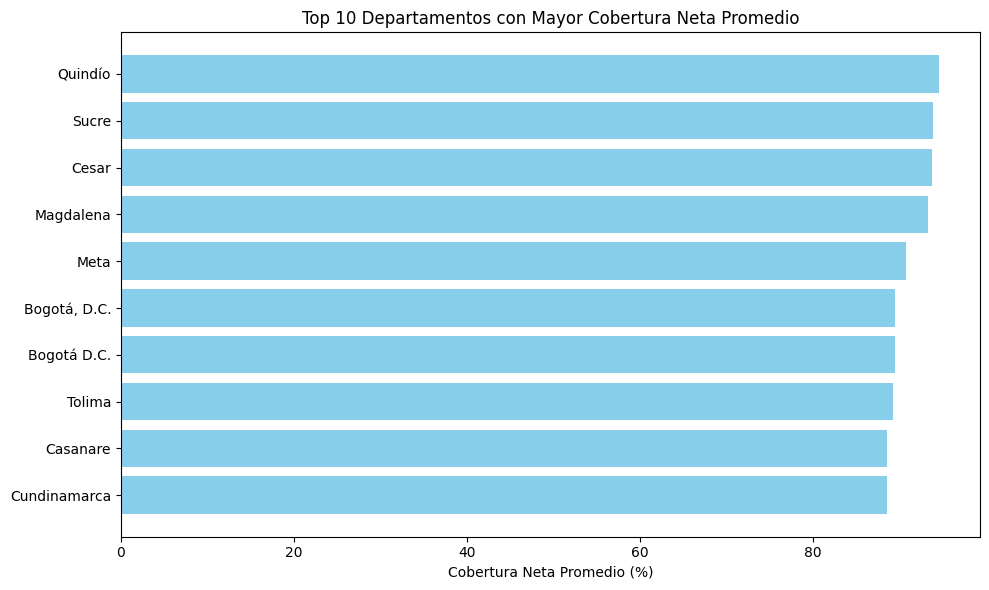

In [7]:
import matplotlib.pyplot as plt

query_plot = '''
SELECT departamento, ROUND(AVG(COBERTURA_NETA), 2) AS cobertura_neta_prom
FROM   Fact_Matriculas f
JOIN   Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP  BY departamento
ORDER  BY cobertura_neta_prom DESC
LIMIT 10;
'''
df_plot = pd.read_sql_query(query_plot, conn).drop_duplicates(subset=['departamento'])

plt.figure(figsize=(10, 6))
plt.barh(df_plot['departamento'], df_plot['cobertura_neta_prom'], color='skyblue')
plt.xlabel('Cobertura Neta Promedio (%)')
plt.title('Top 10 Departamentos con Mayor Cobertura Neta Promedio')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



####  Qué se calculó:

Se estimó el **promedio de cobertura neta** por departamento usando el campo `COBERTURA_NETA` (que representa el porcentaje de estudiantes entre 5 y 16 años matriculados en el nivel educativo correspondiente a su edad).

$$
\text{Cobertura Neta Promedio} = \frac{\sum \text{Cobertura Neta}}{\text{Número de años registrados}}
$$

Este indicador fue calculado para cada departamento agregando todos sus municipios en cada año y tomando el promedio.

####  Resultados destacados:

* Departamentos como **Quindío (94.6%)**, **Sucre (93.8%)** y **Cesar (93.7%)** muestran los valores más altos de cobertura neta promedio.
* Zonas amazónicas como **Vaupés** y **Guainía** presentan valores considerablemente más bajos (menores al 60%).



#####  Departamentos con alta cobertura:

* Denotan **una alta capacidad del sistema educativo para absorber a la población escolar**.
* Probablemente cuentan con:

  * Infraestructura adecuada (número de sedes, disponibilidad de grados).
  * Buen acceso físico a las instituciones educativas (vías, transporte escolar).
  * Políticas de matrícula eficaces y sostenidas en el tiempo.
* **Quindío**, por ejemplo, ha sido históricamente un departamento con buenos indicadores sociales, lo cual puede influir en su desempeño educativo.

#####  Departamentos con baja cobertura:

* La baja cobertura neta puede deberse a:

  * **Dispersión geográfica extrema**, como ocurre en departamentos amazónicos.
  * **Comunidades rurales o indígenas alejadas de las cabeceras municipales**.
  * Problemas estructurales como falta de docentes, escasa inversión o baja cobertura de internet.
* En muchos de estos casos, la oferta educativa no logra abarcar de forma efectiva toda la demanda, especialmente en primaria y secundaria.

#####  Consideraciones técnicas:

* La cobertura neta no mide directamente la calidad educativa, sino el **nivel de acceso de los estudiantes al sistema formal**.
* Departamentos con sobrecobertura pueden tener estudiantes de otros departamentos registrados (efecto frontera).
* Es fundamental comparar estos indicadores con **otros factores de contexto socioeconómico y cultural**, como el índice de pobreza multidimensional o los indicadores de ruralidad.

